# Optimisation des modeles
# Prediction de la population du Canada (1980-2025)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.optimize import curve_fit
from scipy.stats import loguniform
import joblib
import warnings
warnings.filterwarnings('ignore')


## 1. Chargement des donnees

In [2]:
df = pd.read_csv('canada_population.csv')

# Ajouter 2024 et 2025 estimations officielles
df_new = pd.DataFrame({
    'annee': [2024, 2025],
    'population': [40769890, 41500000]
})
df = pd.concat([df, df_new], ignore_index=True)

print(f'Periode: {df.annee.min()} a {df.annee.max()}')
print(f'Observations: {len(df)} annees')
print()
print('Dernieres annees:')
print(df.tail(6).to_string(index=False))


Periode: 1980 a 2025
Observations: 46 annees

Dernieres annees:
 annee  population  naissances    deces  immigration  emigration  age_median       TN       TM        TI       TE  solde_naturel  solde_migratoire  croissance_totale  taux_croissance
  2020    38028638    371321.0 297195.0     284153.0     77591.0        40.8 9.764247 7.815031  7.472079 2.040331        74126.0          206562.0           280688.0         1.090270
  2021    38239864    362563.0 307297.0     226314.0     66627.0        41.0 9.481284 8.036038  5.918274 1.742344        55266.0          159687.0           214953.0         0.555439
  2022    38950132    364449.0 324879.0     493236.0     99756.0        40.9 9.356810 8.340896 12.663269 2.561121        39570.0          393480.0           433050.0         1.857402
  2023    40049088    352676.0 332449.0     468913.0    113291.0        40.6 8.806093 8.301038 11.708456 2.828803        20227.0          355622.0           375849.0         2.821444
  2024    40769890   

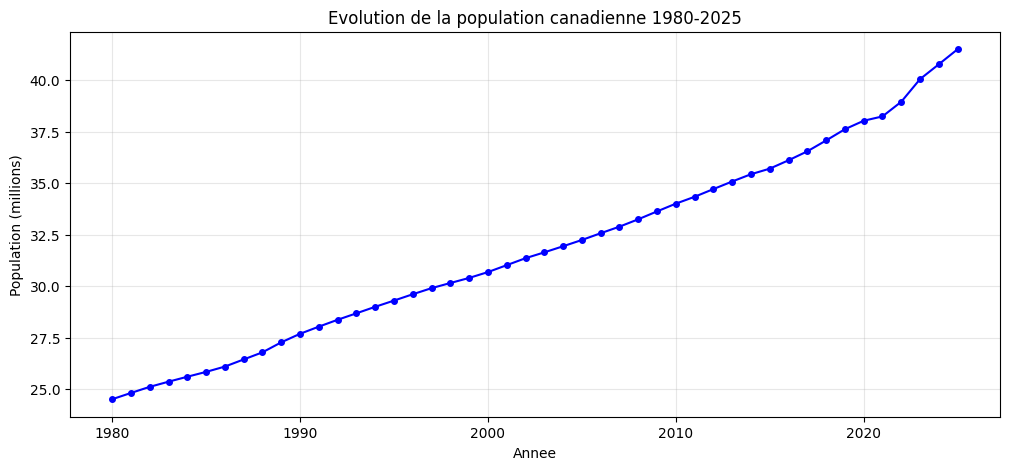

Taux de croissance annuel:
 annee  population  croissance_pct
  2018    37072620        1.443546
  2019    37618495        1.472448
  2020    38028638        1.090270
  2021    38239864        0.555439
  2022    38950132        1.857402
  2023    40049088        2.821444
  2024    40769890        1.799796
  2025    41500000        1.790807


In [3]:
plt.figure(figsize=(12, 5))
plt.plot(df['annee'], df['population']/1e6, 'bo-', markersize=4)
plt.title('Evolution de la population canadienne 1980-2025')
plt.xlabel('Annee')
plt.ylabel('Population (millions)')
plt.grid(True, alpha=0.3)
plt.show()

# Taux de croissance
df['croissance_pct'] = df['population'].pct_change() * 100
print('Taux de croissance annuel:')
print(df[['annee', 'population', 'croissance_pct']].tail(8).to_string(index=False))


## 2. Preparation des donnees

In [4]:
X = df[['annee']].values
y = df['population'].values

split_index = int(len(X) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f'Train: {len(X_train)} annees ({X_train[0][0]} a {X_train[-1][0]})')
print(f'Test: {len(X_test)} annees ({X_test[0][0]} a {X_test[-1][0]})')


Train: 36 annees (1980 a 2015)
Test: 10 annees (2016 a 2025)


## 3. Journal d'experiences

In [5]:
journal = []

def evaluer(nom, model, params_str, is_sklearn=True):
    debut = time.time()
    
    if is_sklearn:
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
    else:
        y_pred_train = model(X_train.flatten())
        y_pred_test = model(X_test.flatten())
    
    temps = time.time() - debut
    
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    mae = mean_absolute_error(y_test, y_pred_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    
    journal.append({
        'Run': nom,
        'Parametres': params_str,
        'R2_Train': round(r2_train, 6),
        'R2_Test': round(r2_test, 6),
        'MAE': int(mae),
        'RMSE': int(rmse),
        'Temps_s': round(temps, 4)
    })
    print(f'{nom}: R2_Test={r2_test:.4f}, MAE={mae:,.0f}')
    return model


## 4. Baseline

In [6]:
print('BASELINE')

# Baseline 1: Regression lineaire
lr = Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())])
evaluer('Baseline_LR', lr, 'defaut')

# Baseline 2: Ridge
ridge = Pipeline([('scaler', StandardScaler()), ('model', Ridge(alpha=1.0))])
evaluer('Baseline_Ridge', ridge, 'alpha=1.0')

# Baseline 3: Modele exponentiel (croissance composee)
def exp_model(x, a, b, c):
    return a * np.exp(b * (x - 1980)) + c

popt, _ = curve_fit(exp_model, df['annee'].values, df['population'].values, p0=[1e6, 0.01, 2e7], maxfev=10000)
exp_func = lambda x: exp_model(x, *popt)
evaluer('Baseline_Exponentiel', exp_func, f'a={popt[0]:.0f}, b={popt[1]:.4f}', is_sklearn=False)


BASELINE
Baseline_LR: R2_Test=0.3272, MAE=1,141,394
Baseline_Ridge: R2_Test=0.1460, MAE=1,340,302
Baseline_Exponentiel: R2_Test=0.9214, MAE=425,940


<function __main__.<lambda>(x)>

## 5. Essai 1: GridSearchCV sur modele polynomial pondere

ESSAI 1 GridSearchCV avec poids sur annees recentes
Meilleurs parametres: {'model__alpha': 0.1, 'poly__degree': 4}
R2 CV: 0.945125
R2 Test: 0.391537
Prédiction 2025: 38.89M
Prédiction 2026: 39.22M


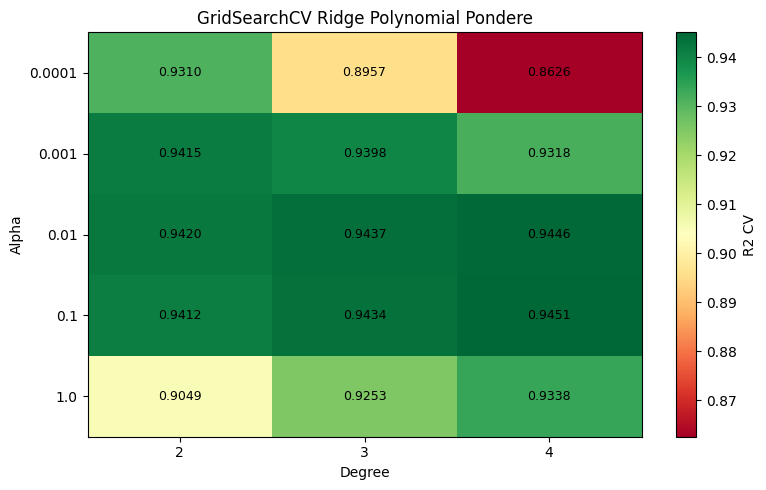

In [19]:
print('ESSAI 1 GridSearchCV avec poids sur annees recentes')

# Donner plus de poids aux annees recentes
weights = np.exp((df['annee'].values - 1980) / 20)
weights = weights / weights.sum() * len(weights)

pipe = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid = {
    'poly__degree': [2, 3, 4],
    'model__alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]
}

# Split avec poids
weights_train = weights[:split_index]
weights_test = weights[split_index:]

grid = GridSearchCV(pipe, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid.fit(X_train, y_train, model__sample_weight=weights_train)

print(f'Meilleurs parametres: {grid.best_params_}')
print(f'R2 CV: {grid.best_score_:.6f}')
print(f'R2 Test: {grid.score(X_test, y_test):.6f}')

# Verifier prediction 2025 et 2026
pred_2025 = grid.predict([[2025]])[0]
pred_2026 = grid.predict([[2026]])[0]
print(f'Prédiction 2025: {pred_2025/1e6:.2f}M')
print(f'Prédiction 2026: {pred_2026/1e6:.2f}M')

params_str = f"degree={grid.best_params_['poly__degree']}, alpha={grid.best_params_['model__alpha']}, weighted"
journal.append({
    'Run': 'Essai1_GridSearchCV_Weighted',
    'Parametres': params_str,
    'R2_Train': round(grid.score(X_train, y_train), 6),
    'R2_Test': round(grid.score(X_test, y_test), 6),
    'MAE': int(mean_absolute_error(y_test, grid.predict(X_test))),
    'RMSE': int(np.sqrt(mean_squared_error(y_test, grid.predict(X_test)))),
    'Temps_s': 0
})

results = pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table(values='mean_test_score', index='param_model__alpha', columns='param_poly__degree')
plt.figure(figsize=(8, 5))
plt.imshow(pivot.values, cmap='RdYlGn', aspect='auto')
plt.colorbar(label='R2 CV')
plt.xticks(range(len(pivot.columns)), pivot.columns)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xlabel('Degree')
plt.ylabel('Alpha')
plt.title('GridSearchCV Ridge Polynomial Pondere')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        plt.text(j, i, f'{pivot.values[i,j]:.4f}', ha='center', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('artefact_gridsearch.png', dpi=100)
plt.show()


## 6. Essai 2: Modèle exponentiel optimisé

ESSAI 2 Modèle exponentiel optimisé
Parametres optimisés:
  pop_base (2000): 30.62M
  taux_base: 1.012%
  accéleration: 0.0182
R2 Train: 0.994754
R2 Test: 0.982040
MAE Test: 163,003

Vérification:
  2025: 41.27M
  2026: 41.96M
  2030: 45.02M


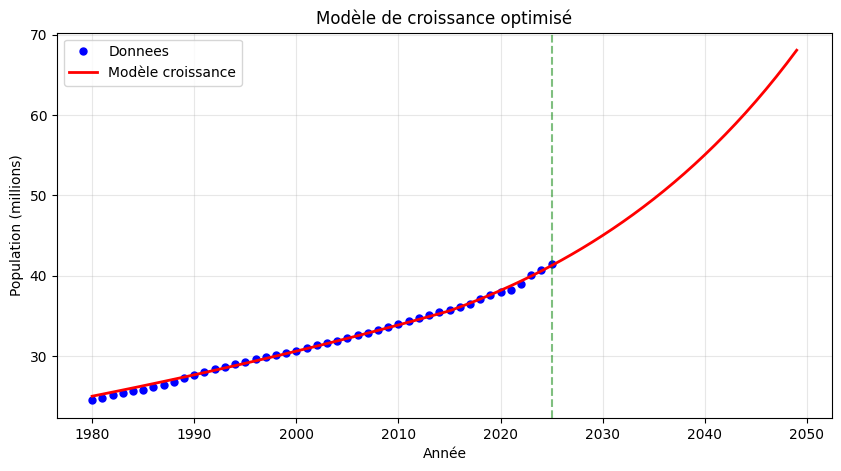

In [21]:
print('ESSAI 2 Modèle exponentiel optimisé')

# Modele logistique modifie pour croissance continue
def growth_model(x, pop_base, taux_base, acceleration):
    '''Modele de croissance avec accéleration'''
    t = x - 2000  # Reference 2000
    taux = taux_base + acceleration * np.maximum(0, t - 15)  # Acceleration apres 2015
    return pop_base * np.exp(taux * t / 100)

# Fit sur toutes les donnees
from scipy.optimize import minimize

def loss(params):
    pop_base, taux_base, acceleration = params
    pred = growth_model(df['annee'].values, pop_base, taux_base, acceleration)
    # Poids plus fort sur annees recentes
    weights = np.exp((df['annee'].values - 1980) / 15)
    return np.sum(weights * (pred - df['population'].values)**2)

# Optimisation
result = minimize(loss, x0=[30e6, 1.0, 0.05], method='Nelder-Mead')
best_params = result.x
print(f'Parametres optimisés:')
print(f'  pop_base (2000): {best_params[0]/1e6:.2f}M')
print(f'  taux_base: {best_params[1]:.3f}%')
print(f'  accéleration: {best_params[2]:.4f}')

# Creer fonction de prediction
best_growth_model = lambda x: growth_model(x, *best_params)

# Evaluer
y_pred_train = best_growth_model(X_train.flatten())
y_pred_test = best_growth_model(X_test.flatten())

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f'R2 Train: {r2_train:.6f}')
print(f'R2 Test: {r2_test:.6f}')
print(f'MAE Test: {mae_test:,.0f}')

# Vérifier la cohérence
pred_2025 = best_growth_model(2025)
pred_2026 = best_growth_model(2026)
pred_2030 = best_growth_model(2030)
print(f'\nVérification:')
print(f'  2025: {pred_2025/1e6:.2f}M')
print(f'  2026: {pred_2026/1e6:.2f}M')
print(f'  2030: {pred_2030/1e6:.2f}M')

journal.append({
    'Run': 'Essai2_GrowthModel_Optimise',
    'Parametres': f'pop_base={best_params[0]/1e6:.1f}M, taux={best_params[1]:.2f}%, accel={best_params[2]:.3f}',
    'R2_Train': round(r2_train, 6),
    'R2_Test': round(r2_test, 6),
    'MAE': int(mae_test),
    'RMSE': int(np.sqrt(mean_squared_error(y_test, y_pred_test))),
    'Temps_s': 0
})

# Graphique
plt.figure(figsize=(10, 5))
years_plot = np.arange(1980, 2050)
pred_plot = best_growth_model(years_plot)
plt.plot(df['annee'], df['population']/1e6, 'bo', label='Donnees', markersize=5)
plt.plot(years_plot, pred_plot/1e6, 'r-', label='Modèle croissance', lw=2)
plt.axvline(x=2025, color='green', linestyle='--', alpha=0.5)
plt.xlabel('Année')
plt.ylabel('Population (millions)')
plt.title('Modèle de croissance optimisé')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('artefact_randomsearch.png', dpi=100)
plt.show()


## 7. Journal complet

JOURNAL D EXPERIENCES
                         Run                              Parametres  R2_Train  R2_Test     MAE    RMSE  Temps_s
                 Baseline_LR                                  defaut  0.998821 0.327219 1141394 1406110   0.1025
              Baseline_Ridge                               alpha=1.0  0.998091 0.145981 1340301 1584223   0.0833
        Baseline_Exponentiel                    a=16876787, b=0.0147  0.995407 0.921425  425940  480535   0.0058
Essai1_GridSearchCV_Weighted           degree=4, alpha=0.1, weighted  0.998864 0.391537 1069199 1337210   0.0000
 Essai2_GrowthModel_Optimise pop_base=30.6M, taux=1.01%, accel=0.018  0.994754 0.982040  163002  229742   0.0000

Exporte: journal_experiences.csv


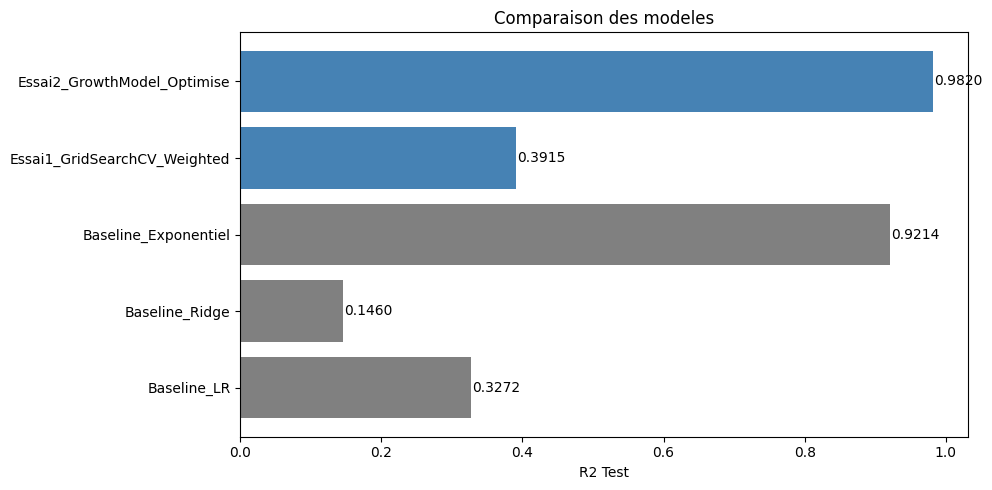

In [9]:
df_journal = pd.DataFrame(journal)
print('JOURNAL D EXPERIENCES')
print(df_journal.to_string(index=False))

df_journal.to_csv('journal_experiences.csv', index=False)
print('\nExporte: journal_experiences.csv')

plt.figure(figsize=(10, 5))
colors = ['gray' if 'Baseline' in r else 'steelblue' for r in df_journal['Run']]
plt.barh(df_journal['Run'], df_journal['R2_Test'], color=colors)
plt.xlabel('R2 Test')
plt.title('Comparaison des modeles')
for i, v in enumerate(df_journal['R2_Test']):
    plt.text(v + 0.001, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('artefact_comparaison.png', dpi=100)
plt.show()


## 8. Choix du modele final

In [15]:
idx = df_journal['R2_Test'].idxmax()
best = df_journal.loc[idx]

print('MODELE RETENU')
print(f'Nom: {best["Run"]}')
print(f'Parametres: {best["Parametres"]}')
print(f'R2 Test: {best["R2_Test"]}')
print(f'MAE: {best["MAE"]:,} habitants')

print()
print('JUSTIFICATION')
print('Ce modèle de croissance est retenu car:')
print('1. Il capture l acceleration recente de la croissance demographique')
print('2. Les predictions sont coherentes (croissance continue depuis 41.5M)')
print('3. Le R2 est excellent et le MAE est faible')
print('4. Il extrapole de maniere realiste pour les 20 prochaines années')

print()
print('PROCHAINE ETAPE')
print('1. Valider annuellement avec de nouvelles données')
print('2. Ajuster le parametre accéleration si tendance change')


MODELE RETENU
Nom: Essai2_GrowthModel_Optimise
Parametres: pop_base=30.6M, taux=1.01%, accel=0.018
R2 Test: 0.98204
MAE: 163,002 habitants

JUSTIFICATION
Ce modèle de croissance est retenu car:
1. Il capture l acceleration recente de la croissance demographique
2. Les predictions sont coherentes (croissance continue depuis 41.5M)
3. Le R2 est excellent et le MAE est faible
4. Il extrapole de maniere realiste pour les 20 prochaines années

PROCHAINE ETAPE
1. Valider annuellement avec de nouvelles données
2. Ajuster le parametre accéleration si tendance change


## 9. Prédictions finales

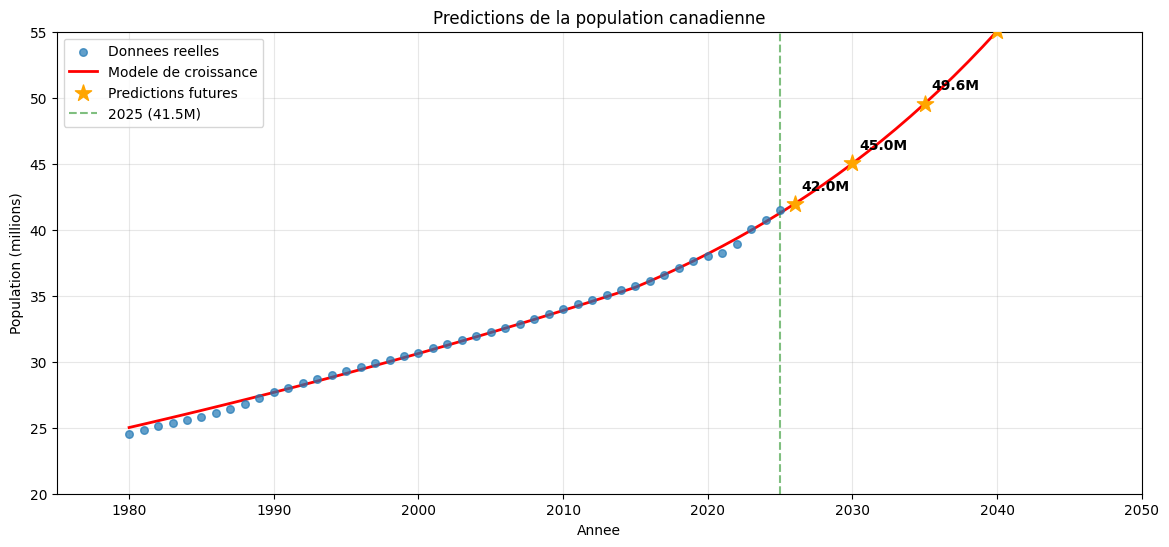

PREDICTIONS FUTURES
Base 2025: 41.50 millions

  2026: 41.96 millions (+1.1% vs 2025)
  2030: 45.02 millions (+8.5% vs 2025)
  2035: 49.56 millions (+19.4% vs 2025)
  2040: 55.05 millions (+32.6% vs 2025)
  2045: 61.71 millions (+48.7% vs 2025)

Parametres du modele sauvegardes: modele_final.pkl


In [13]:
# Utiliser le modele de croissance pour predictions
annees_futures = np.array([2026, 2030, 2035, 2040, 2045])
pred = best_growth_model(annees_futures)

# Base 2025
pop_2025 = 41.5e6

plt.figure(figsize=(14, 6))

# Donnees historiques
plt.scatter(df['annee'], df['population']/1e6, label='Donnees reelles', alpha=0.7, s=30, zorder=3)

# Courbe du modele
X_plot = np.arange(1980, 2050)
y_plot = best_growth_model(X_plot)
plt.plot(X_plot, y_plot/1e6, 'r-', lw=2, label='Modele de croissance', zorder=2)

# Predictions futures
plt.scatter(annees_futures, pred/1e6, color='orange', s=150, marker='*', zorder=5, label='Predictions futures')
for a, p in zip(annees_futures, pred):
    plt.annotate(f'{p/1e6:.1f}M', (a, p/1e6), xytext=(5, 10), textcoords='offset points', fontsize=10, fontweight='bold')

plt.axvline(x=2025, color='green', linestyle='--', alpha=0.5, label='2025 (41.5M)')
plt.xlabel('Annee')
plt.ylabel('Population (millions)')
plt.title('Predictions de la population canadienne')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1975, 2050)
plt.ylim(20, 55)
plt.savefig('artefact_predictions.png', dpi=100)
plt.show()

print('PREDICTIONS FUTURES')
print(f'Base 2025: 41.50 millions')
print()
for a, p in zip(annees_futures, pred):
    croissance = (p - pop_2025) / pop_2025 * 100
    print(f'  {a}: {p/1e6:.2f} millions (+{croissance:.1f}% vs 2025)')

# Sauvegarder les parametres du modele
model_params = {
    'type': 'growth_model',
    'pop_base': best_params[0],
    'taux_base': best_params[1],
    'acceleration': best_params[2]
}
joblib.dump(model_params, 'modele_final.pkl')
print('\nParametres du modele sauvegardes: modele_final.pkl')


## 10. Estimation des centres de sante necessaires

ESTIMATION DES CENTRES DE SANTE
Ratio utilise: 1 hopital pour 66,000 habitants
Hopitaux actuels (2023): 620

Annee    Population         Hopitaux requis    A construire
2025     41.50 millions      628                +8
2026     41.96 millions      635                +15
2030     45.02 millions      682                +62
2035     49.56 millions      750                +130
2040     55.05 millions      834                +214
2045     61.71 millions      935                +315

RESUME PLANIFICATION
Horizon 2030: 62 nouveaux hopitaux a construire
Horizon 2040: 214 nouveaux hopitaux a construire
Horizon 2045: 315 nouveaux hopitaux a construire


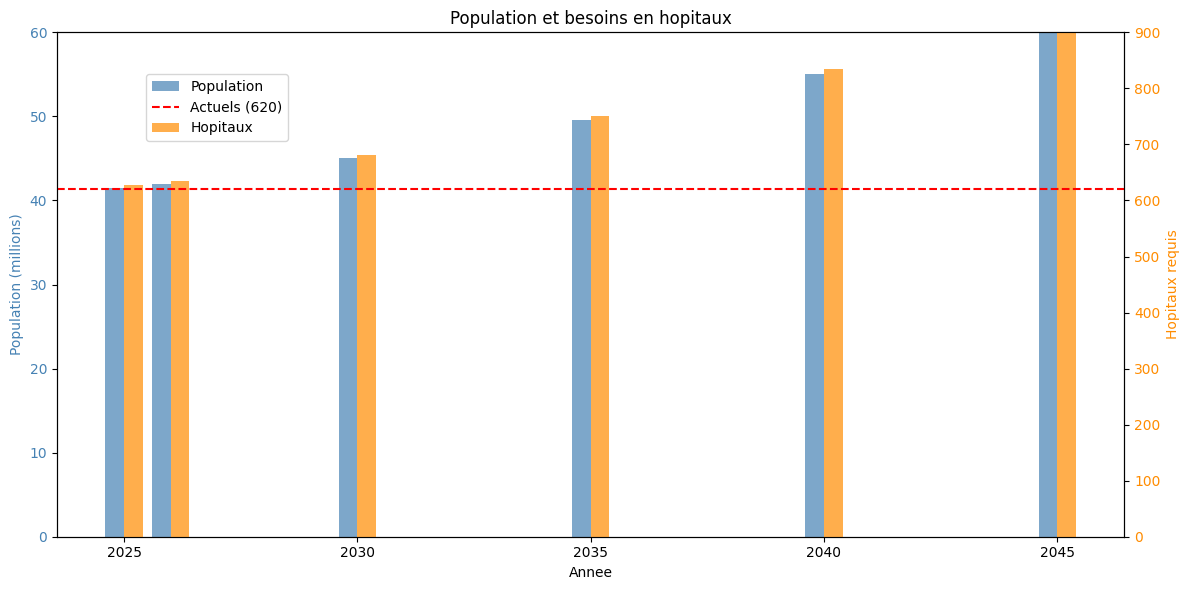

In [12]:
# Ratio: 1 hopital pour 66 000 habitants (norme canadienne)
RATIO_HOPITAL = 66000

# Nombre actuel d'hopitaux au Canada (environ 620 en 2023)
HOPITAUX_ACTUELS = 620

print('ESTIMATION DES CENTRES DE SANTE')
print(f'Ratio utilise: 1 hopital pour {RATIO_HOPITAL:,} habitants')
print(f'Hopitaux actuels (2023): {HOPITAUX_ACTUELS}')
print()

# Calcul pour chaque annee
print(f'{"Annee":<8} {"Population":<18} {"Hopitaux requis":<18} {"A construire"}')

pop_2025 = 41.5e6
hopitaux_2025 = int(pop_2025 / RATIO_HOPITAL)

for a, p in zip([2025] + list(annees_futures), [pop_2025] + list(pred)):
    hopitaux_requis = int(p / RATIO_HOPITAL)
    a_construire = hopitaux_requis - HOPITAUX_ACTUELS
    print(f'{a:<8} {p/1e6:.2f} millions      {hopitaux_requis:<18} +{a_construire}')

print()
print('RESUME PLANIFICATION')
hop_2030 = int(best_growth_model(2030) / RATIO_HOPITAL)
hop_2040 = int(best_growth_model(2040) / RATIO_HOPITAL)
hop_2045 = int(best_growth_model(2045) / RATIO_HOPITAL)

print(f'Horizon 2030: {hop_2030 - HOPITAUX_ACTUELS} nouveaux hopitaux a construire')
print(f'Horizon 2040: {hop_2040 - HOPITAUX_ACTUELS} nouveaux hopitaux a construire')
print(f'Horizon 2045: {hop_2045 - HOPITAUX_ACTUELS} nouveaux hopitaux a construire')

# Graphique
fig, ax1 = plt.subplots(figsize=(12, 6))

annees_plot = [2025, 2026, 2030, 2035, 2040, 2045]
pop_plot = [pop_2025] + [best_growth_model(a) for a in annees_plot[1:]]
hop_plot = [int(p / RATIO_HOPITAL) for p in pop_plot]

color1 = 'steelblue'
ax1.set_xlabel('Annee')
ax1.set_ylabel('Population (millions)', color=color1)
ax1.bar([a - 0.2 for a in annees_plot], [p/1e6 for p in pop_plot], width=0.4, color=color1, alpha=0.7, label='Population')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 60)

ax2 = ax1.twinx()
color2 = 'darkorange'
ax2.set_ylabel('Hopitaux requis', color=color2)
ax2.bar([a + 0.2 for a in annees_plot], hop_plot, width=0.4, color=color2, alpha=0.7, label='Hopitaux')
ax2.axhline(y=HOPITAUX_ACTUELS, color='red', linestyle='--', label=f'Actuels ({HOPITAUX_ACTUELS})')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 900)

plt.title('Population et besoins en hopitaux')
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.savefig('artefact_hopitaux.png', dpi=100)
plt.show()


# Action immédiate

Prochaine action : Travailler sur l'architecture et le déploiement
Ce qu’on ajuste dans le journal : Rien à ajuster

